# ******PATHOLOGY LAB ANALYSIS******
### PROJECT TYPE:-EDA

# OVERVIEW:Analyzing the Impact of Clinical Parameters on Disease Diagnosis
This project aims to explore how different clinical parameters influence the occurrence of various diseases, specifically **Normal, Inflammation, Infection, Viral, and Anemia**. The workflow involves data preprocessing, optimization, and visualization to extract meaningful insights from medical data.

## 1️⃣ Data Preprocessing & Optimization:
- The raw dataset is first collected, containing key clinical markers such as:
- CRP (C-Reactive Protein) → Inflammation indicator.
- Haemoglobin → Measures oxygen-carrying capacity of blood.
- Platelet Count & Total WBC → Indicators of immune system activity.
- The dataset undergoes cleaning by removing NA values and ensuring standardization for consistency.
- Dataset improvement: When a single row contained multiple diseases,  modification on the dataset was done by splitting it into separate rows for each disease, making the analysis more structured and precise.
## 2️⃣ Exploratory Data Analysis (EDA) & Visualization:
- Various visualization techniques (count plots, violin plots) are used to analyze patterns between clinical values and disease categories.
- Key relationships explored include:
    - How CRP levels differentiate between Normal, Inflammation, and Infection.
    - The impact of Haemoglobin levels on conditions like Anemia.
    - Total WBC and Platelet Count variations across different diseases especially viral disease .
## 3️⃣ Insights & Disease Patterns:
- Normal → Patients with stable blood parameters.
- Inflammation → Elevated CRP and moderate immune response.
- Infection → Higher WBC count and CRP values.
- Viral → Lower WBC counts with varying platelet levels.
- Anemia → Reduced haemoglobin levels.
By systematically analyzing these clinical markers, this project provides a data-driven understanding of disease patterns, helping in better diagnostics and medical decision-making.
    
    

## Columns and their meanings:

- `MONTH`: The month in which the patient visited the hospital.  
- `AGE`: The age of the patient at the time of the visit.  
- `SEX`: The biological sex of the patient (Male/Female).  
- `HAEMOGLOBIN`: Count of a protein in red blood cells responsible for carrying oxygen.  
- `TWbc`: Total White Blood Cell count, indicating immune response.  
- `PlateletCount`: The number of platelets in the blood, essential for clotting.  
- `CRP`: C-Reactive Protein, a blood marker indicating inflammation or infection.  
- `Pid`: Patient ID, a unique identifier assigned to each patient.  
- `IGM`: Immunoglobulin M, an antibody that signals recent or ongoing infection.  
- `DISEASE`: The diagnosed medical condition based on clinical and lab findings.  


#### Import Libraries


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import matplotlib.image as mpimg
import textwrap
import warnings
import numpy as np
warnings.filterwarnings("ignore")
import xgboost as xgb
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import matplotlib.gridspec as gridspec

#### Reading of data 

In [2]:
df=pd.read_excel("dataset.xlsx")
print(df.shape)
df.head()

(489, 11)


,INDEX,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,IGM,DISEASE
0,1.0,3.0,7.0,M,10.5,5200.0,214000.0,2.30,15861.0,NaN,NORMAL
1,2.0,3.0,2.3,M,10.1,15300.0,368000.0,27.26,15834.0,NaN,INFECTION
2,3.0,3.0,6.0,M,10.1,4200.0,243000.0,2.67,NaN,NaN,NORMAL
3,4.0,3.0,7.5,M,11.9,6200.0,360000.0,3.55,NaN,NaN,NORMAL
4,5.0,3.0,8.0,M,11.2,7100.0,224000.0,4.31,NaN,NaN,INFLAMATION


#### Data Preprocessing

In [3]:
df=df.drop(columns=['INDEX','IGM'],axis=1)

In [4]:
df=df.dropna(subset=["DISEASE"])
print(df.shape)
df.head()

(251, 9)


,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
0,3.0,7.0,M,10.5,5200.0,214000.0,2.30,15861.0,NORMAL
1,3.0,2.3,M,10.1,15300.0,368000.0,27.26,15834.0,INFECTION
2,3.0,6.0,M,10.1,4200.0,243000.0,2.67,NaN,NORMAL
3,3.0,7.5,M,11.9,6200.0,360000.0,3.55,NaN,NORMAL
4,3.0,8.0,M,11.2,7100.0,224000.0,4.31,NaN,INFLAMATION


In [5]:
df["DISEASE"].value_counts()

DISEASE
NORMAL                    89
INFECTION                 56
INFLAMATION               25
ANEMIA                    22
ANEMIA+INFECTION          20
VIRAL                     16
ANEMIA+INFLAMATION        12
INFECTION+ANEMIA           5
ANEMIA+VIRAL               2
INFECTON                   1
 ANEMIA INFECTION          1
VIRAL+ANEMIA+INFECTION     1
ANEMIA                     1
Name: count, dtype: int64

In [6]:
mapping = {
    "INFECTON": "INFECTION",
    " ANEMIA INFECTION": "ANEMIA+INFECTION",
    "INFECTION+ANEMIA": "ANEMIA+INFECTION"
}

# Apply map without fillna
df["DISEASE"] = df["DISEASE"].map(mapping).fillna(df["DISEASE"])


In [7]:
df["DISEASE"].value_counts()

DISEASE
NORMAL                    89
INFECTION                 57
ANEMIA+INFECTION          26
INFLAMATION               25
ANEMIA                    22
VIRAL                     16
ANEMIA+INFLAMATION        12
ANEMIA+VIRAL               2
VIRAL+ANEMIA+INFECTION     1
ANEMIA                     1
Name: count, dtype: int64

In [8]:
df.head()

,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
0,3.0,7.0,M,10.5,5200.0,214000.0,2.30,15861.0,NORMAL
1,3.0,2.3,M,10.1,15300.0,368000.0,27.26,15834.0,INFECTION
2,3.0,6.0,M,10.1,4200.0,243000.0,2.67,NaN,NORMAL
3,3.0,7.5,M,11.9,6200.0,360000.0,3.55,NaN,NORMAL
4,3.0,8.0,M,11.2,7100.0,224000.0,4.31,NaN,INFLAMATION


In [9]:
df.isna().sum()

MONTH            0
AGE              0
SEX              0
HAEMOGLOBIN      0
TWbc             0
PlateletCount    0
CRP              0
Pid              4
DISEASE          0
dtype: int64

In [10]:
df.shape

(251, 9)

In [11]:
df[df["Pid"]==15612.0]

,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
22,3.0,1.7,F,9.8,15200.0,398000.0,13.79,15612.0,ANEMIA+INFECTION


#### Separating multiple disease into different rows

In [12]:
df["DISEASE"] = df["DISEASE"].str.strip()
df["DISEASE"] = df["DISEASE"].str.split(r"\+")
df = df.explode("DISEASE").reset_index(drop=True)

In [13]:
df["DISEASE"].value_counts()

DISEASE
NORMAL         89
INFECTION      84
ANEMIA         64
INFLAMATION    37
VIRAL          19
Name: count, dtype: int64

In [14]:
df.shape

(293, 9)

In [15]:
df[df["Pid"]==15715]


,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
12,3.0,1.7,F,7.1,3400.0,237000.0,2.51,15715.0,VIRAL
13,3.0,1.7,F,7.1,3400.0,237000.0,2.51,15715.0,ANEMIA
14,3.0,1.7,F,7.1,3400.0,237000.0,2.51,15715.0,INFECTION


In [16]:
df[df["Pid"]==15612.0]

,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
25,3.0,1.7,F,9.8,15200.0,398000.0,13.79,15612.0,ANEMIA
26,3.0,1.7,F,9.8,15200.0,398000.0,13.79,15612.0,INFECTION


In [17]:
df.head()

,MONTH,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Pid,DISEASE
0,3.0,7.0,M,10.5,5200.0,214000.0,2.30,15861.0,NORMAL
1,3.0,2.3,M,10.1,15300.0,368000.0,27.26,15834.0,INFECTION
2,3.0,6.0,M,10.1,4200.0,243000.0,2.67,NaN,NORMAL
3,3.0,7.5,M,11.9,6200.0,360000.0,3.55,NaN,NORMAL
4,3.0,8.0,M,11.2,7100.0,224000.0,4.31,NaN,INFLAMATION


### Display Main Code

In [18]:
# Visualizing the missing 
def apply_chart_styling(ax, fig, title, subtitle, insight_text, logo_path='logo.png'):

    fig.patch.set_facecolor('#D3D3D3')
    ax.set_facecolor('#D3D3D3')

    fig.text(0.09, 1.05, title, fontsize=18, fontweight='bold', fontfamily='serif')
    fig.text(0.09, 0.99, subtitle, fontsize=12, fontweight='bold', fontfamily='serif')

    # Load and place the logo at the top of the second half (smaller size)
    logo = mpimg.imread(logo_path)
    logo_ax = fig.add_axes([0.85, 0.95, 0.2, 0.2])  # Adjusted position & made it smaller
    logo_ax.imshow(logo)
    logo_ax.axis('off')

    fig.text(0.85, 0.75, 'INSIGHT', fontsize=16, fontweight='bold', fontfamily='serif')

    # Wrap the insight text manually for better formatting
    wrapped_lines = []
    for paragraph in insight_text.split('\n'):
        wrapped_lines.extend(textwrap.wrap(paragraph, width=40))
    wrapped_text = '\n'.join(wrapped_lines)
    
    fig.text(0.85, 0.65, wrapped_text, fontsize=12, fontweight='bold', 
             fontfamily='serif', va="top")

    ax.grid(axis='y', linestyle='-', alpha=0.4)
    ax.set_axisbelow(True)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=12)

    l1 = lines.Line2D([0.83, 0.83], [0, 1], transform=fig.transFigure, figure=fig, color='black', lw=0.3)
    fig.lines.extend([l1])

### Graph 1:Total Disease Count

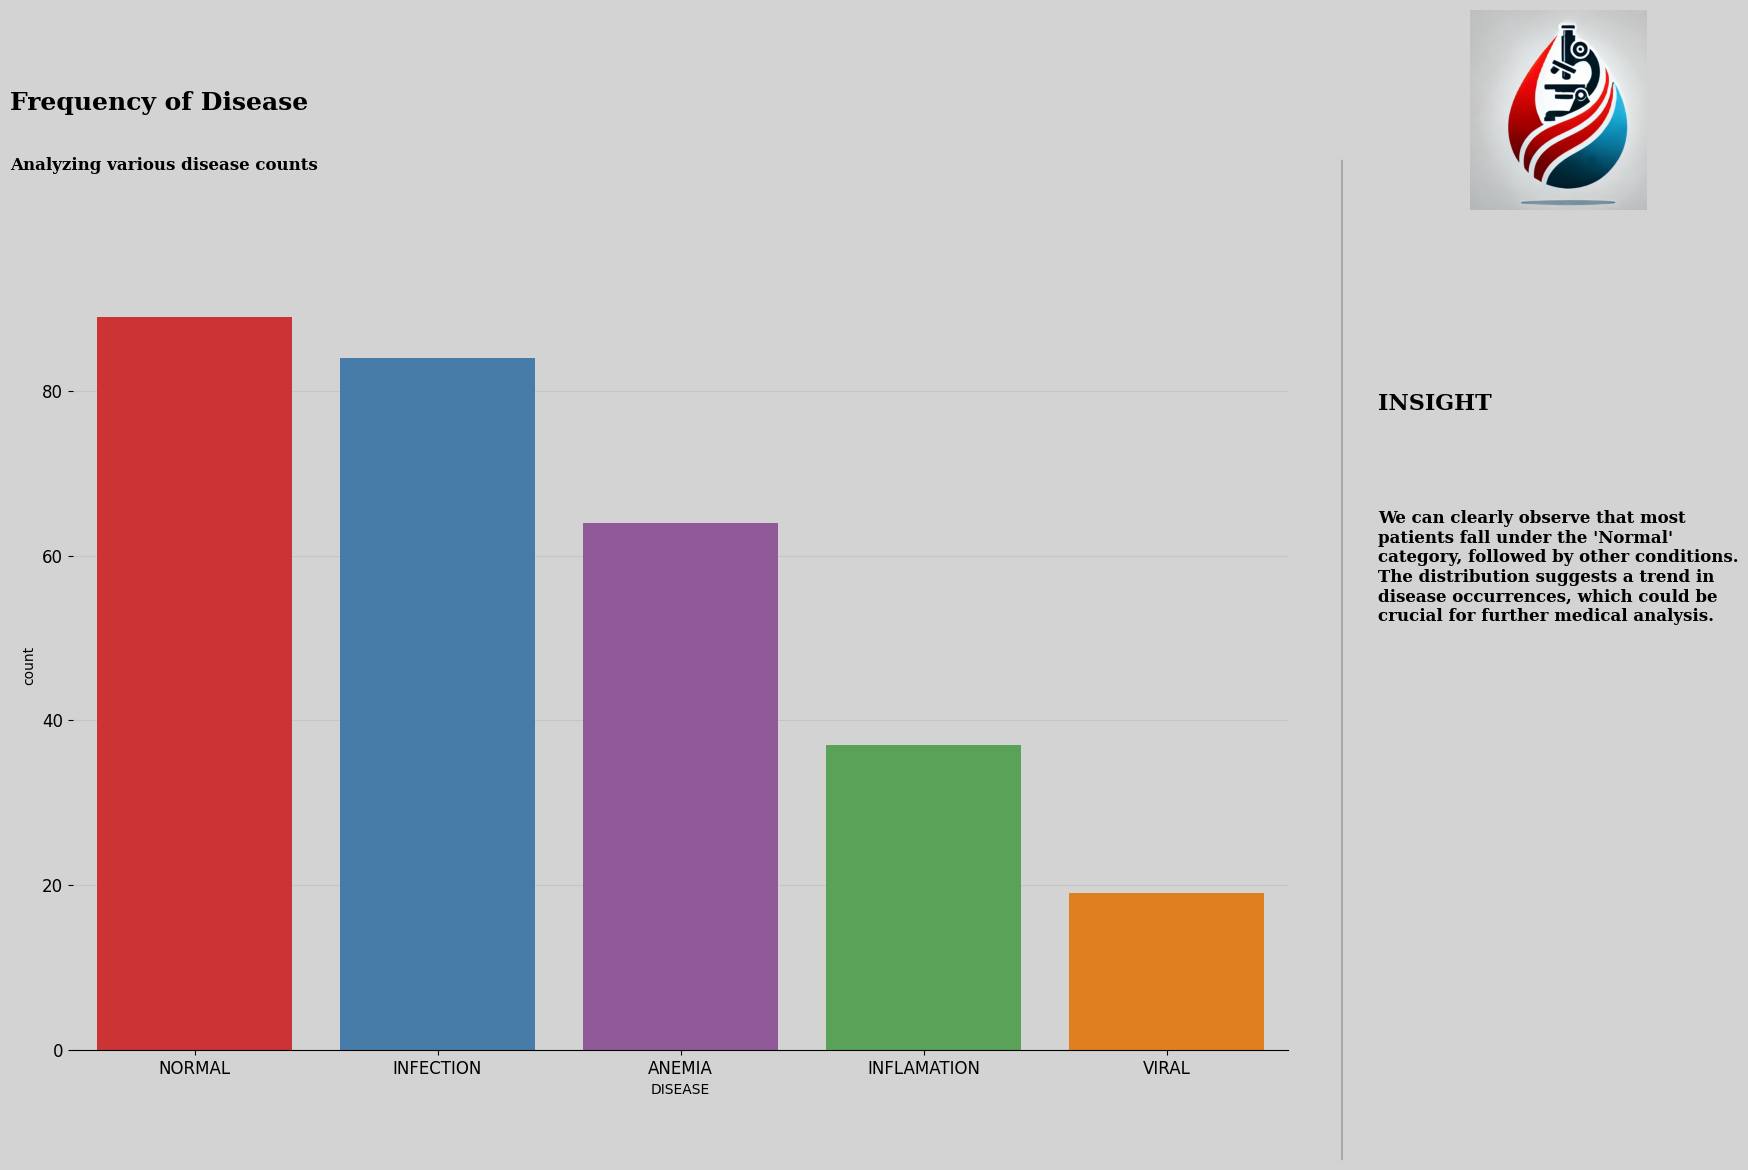

In [19]:

fig, ax = plt.subplots(1, 1, figsize=(18, 10))  # Decreased width
sns.countplot(x="DISEASE", data=df, order=df["DISEASE"].value_counts().index, hue="DISEASE", palette="Set1", legend=False)

# Adjust layout to shift graph left and make room for insights
fig.subplots_adjust(right=0.8)  # Reserves 50% of space for insight

apply_chart_styling(
    ax=ax, 
    fig=fig, 
    title='Frequency of Disease', 
    subtitle='Analyzing various disease counts', 
    insight_text='''We can clearly observe that most patients fall under the 'Normal' category, followed by other conditions.\nThe distribution suggests a trend in disease occurrences, which could be crucial for further medical analysis.''', 
    logo_path="mscope.jpg"
)


### Graph 2:Disease Count Per Month

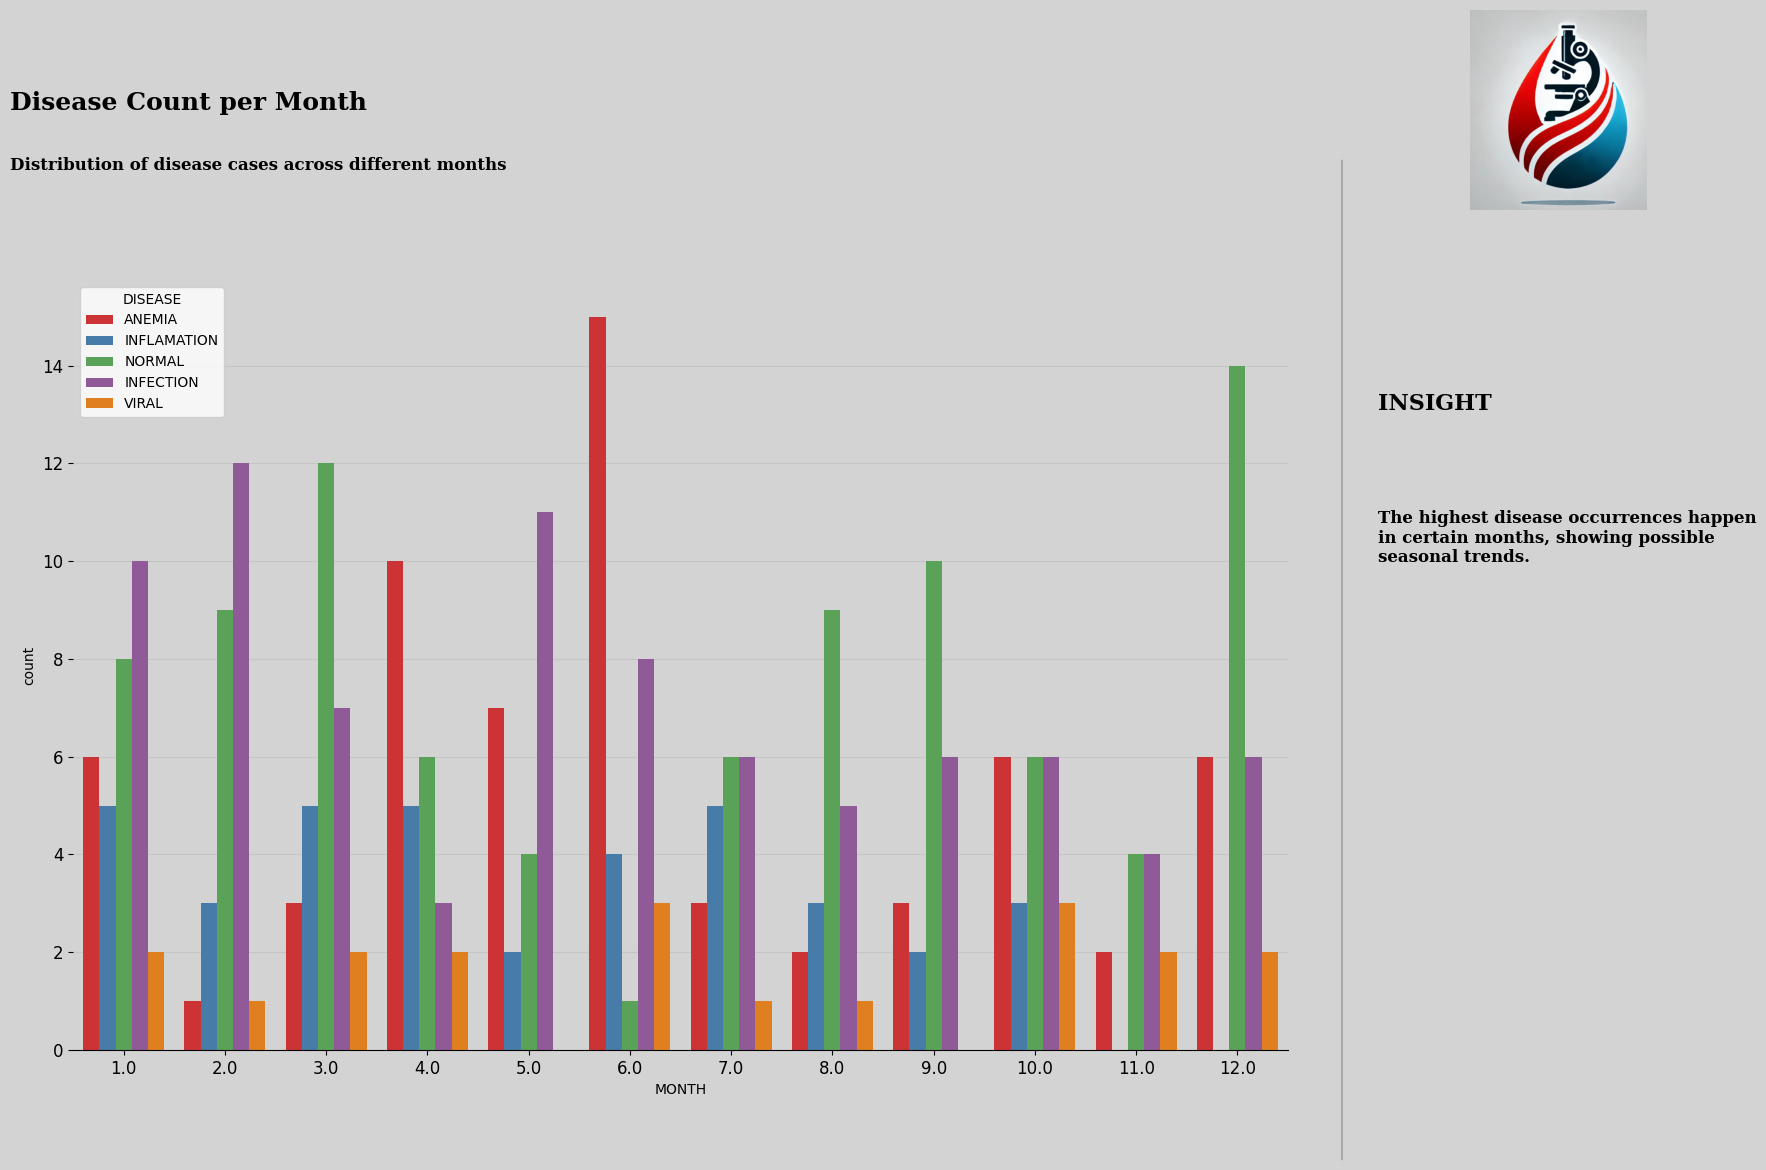

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(18,10 ))
sns.countplot(x="MONTH", hue="DISEASE", data=df, palette="Set1", ax=ax)
fig.subplots_adjust(right=0.8)
apply_chart_styling(ax, fig, title="Disease Count per Month",
                    subtitle="Distribution of disease cases across different months",
                    insight_text="The highest disease occurrences happen in certain months, showing possible seasonal trends.",logo_path="mscope.jpg")

plt.show()

### Graph 3:Disease Count With Respect to Age

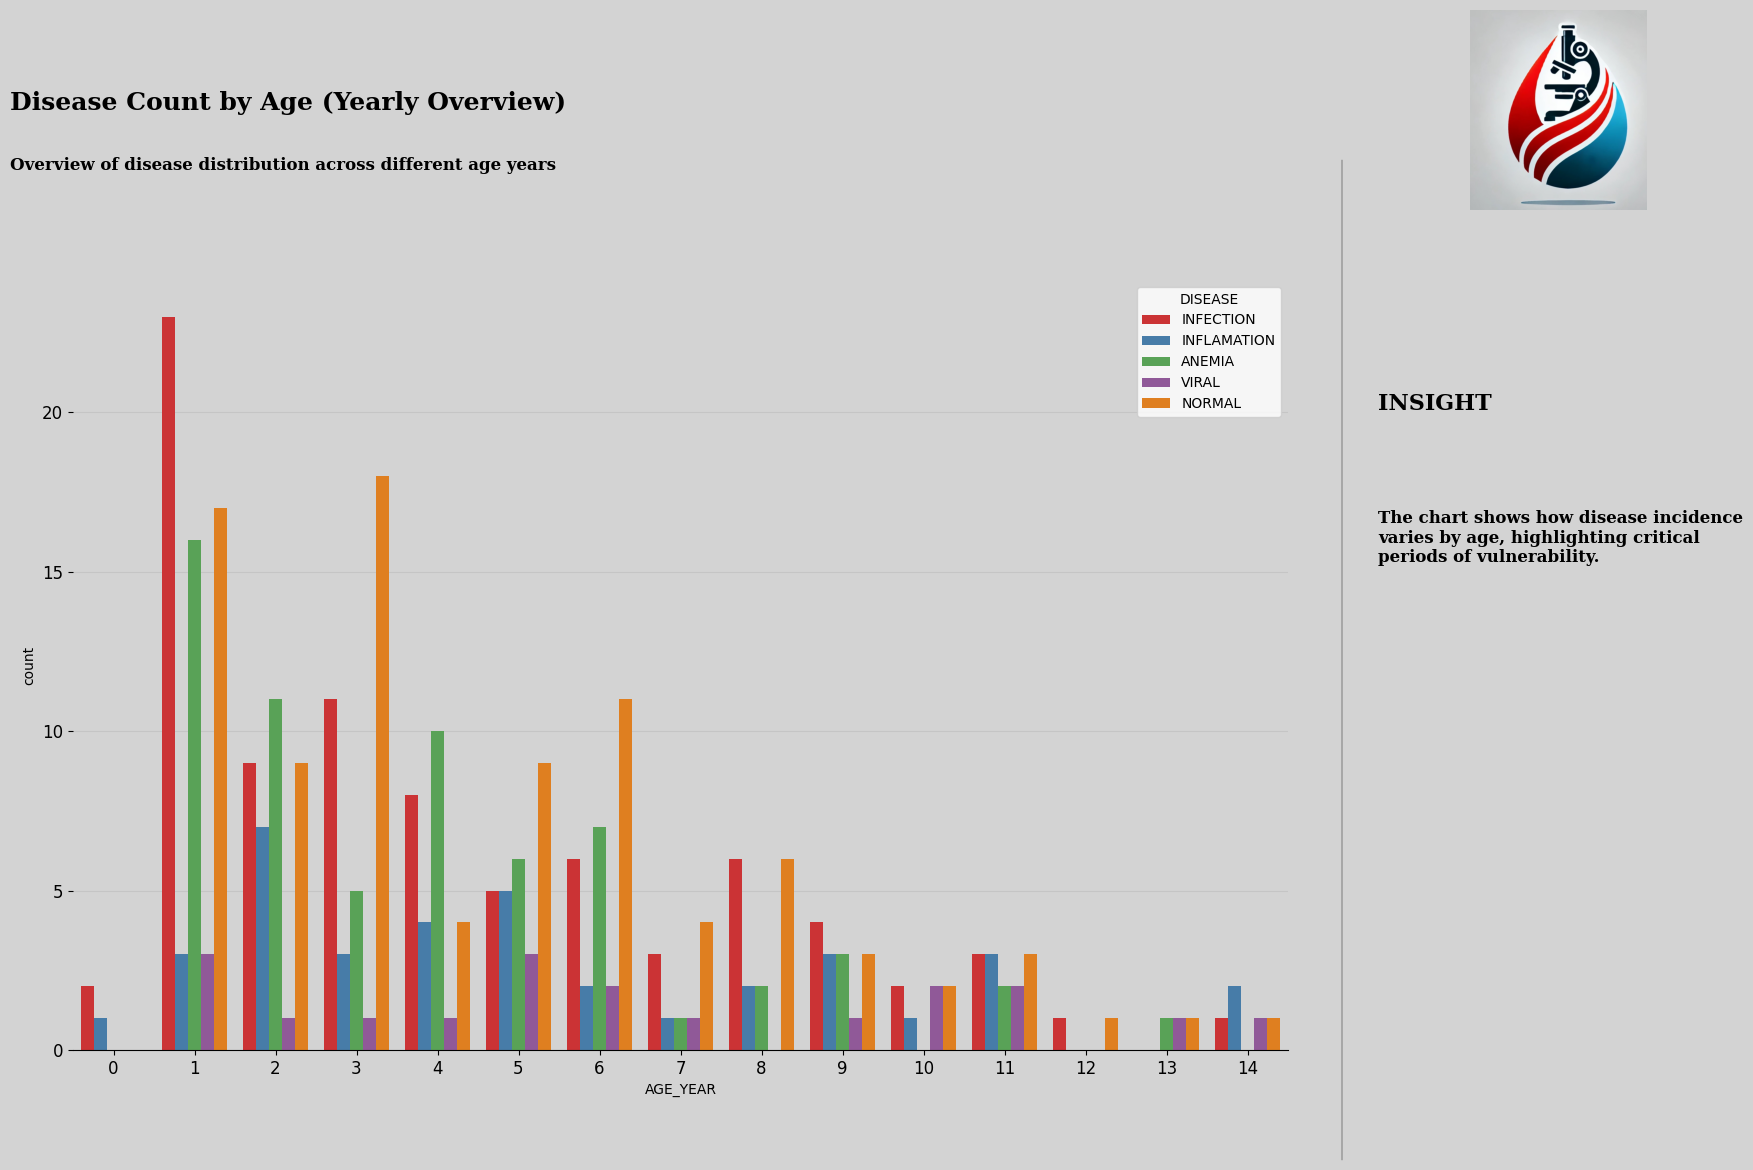

In [50]:
# Create a new column for binned age (rounded down to nearest year)
df["AGE_YEAR"] = df["AGE"].astype(int)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
sns.countplot(x="AGE_YEAR", hue="DISEASE", data=df, palette="Set1", ax=ax)

fig.subplots_adjust(right=0.8)

apply_chart_styling(
    ax,
    fig,
    title="Disease Count by Age (Yearly Overview)",
    subtitle="Overview of disease distribution across different age years",
    insight_text="The chart shows how disease incidence varies by age, highlighting critical periods of vulnerability.",
    logo_path="mscope.jpg"
)

plt.show()


### Graph 4:Haemoglobin Level Visualizer

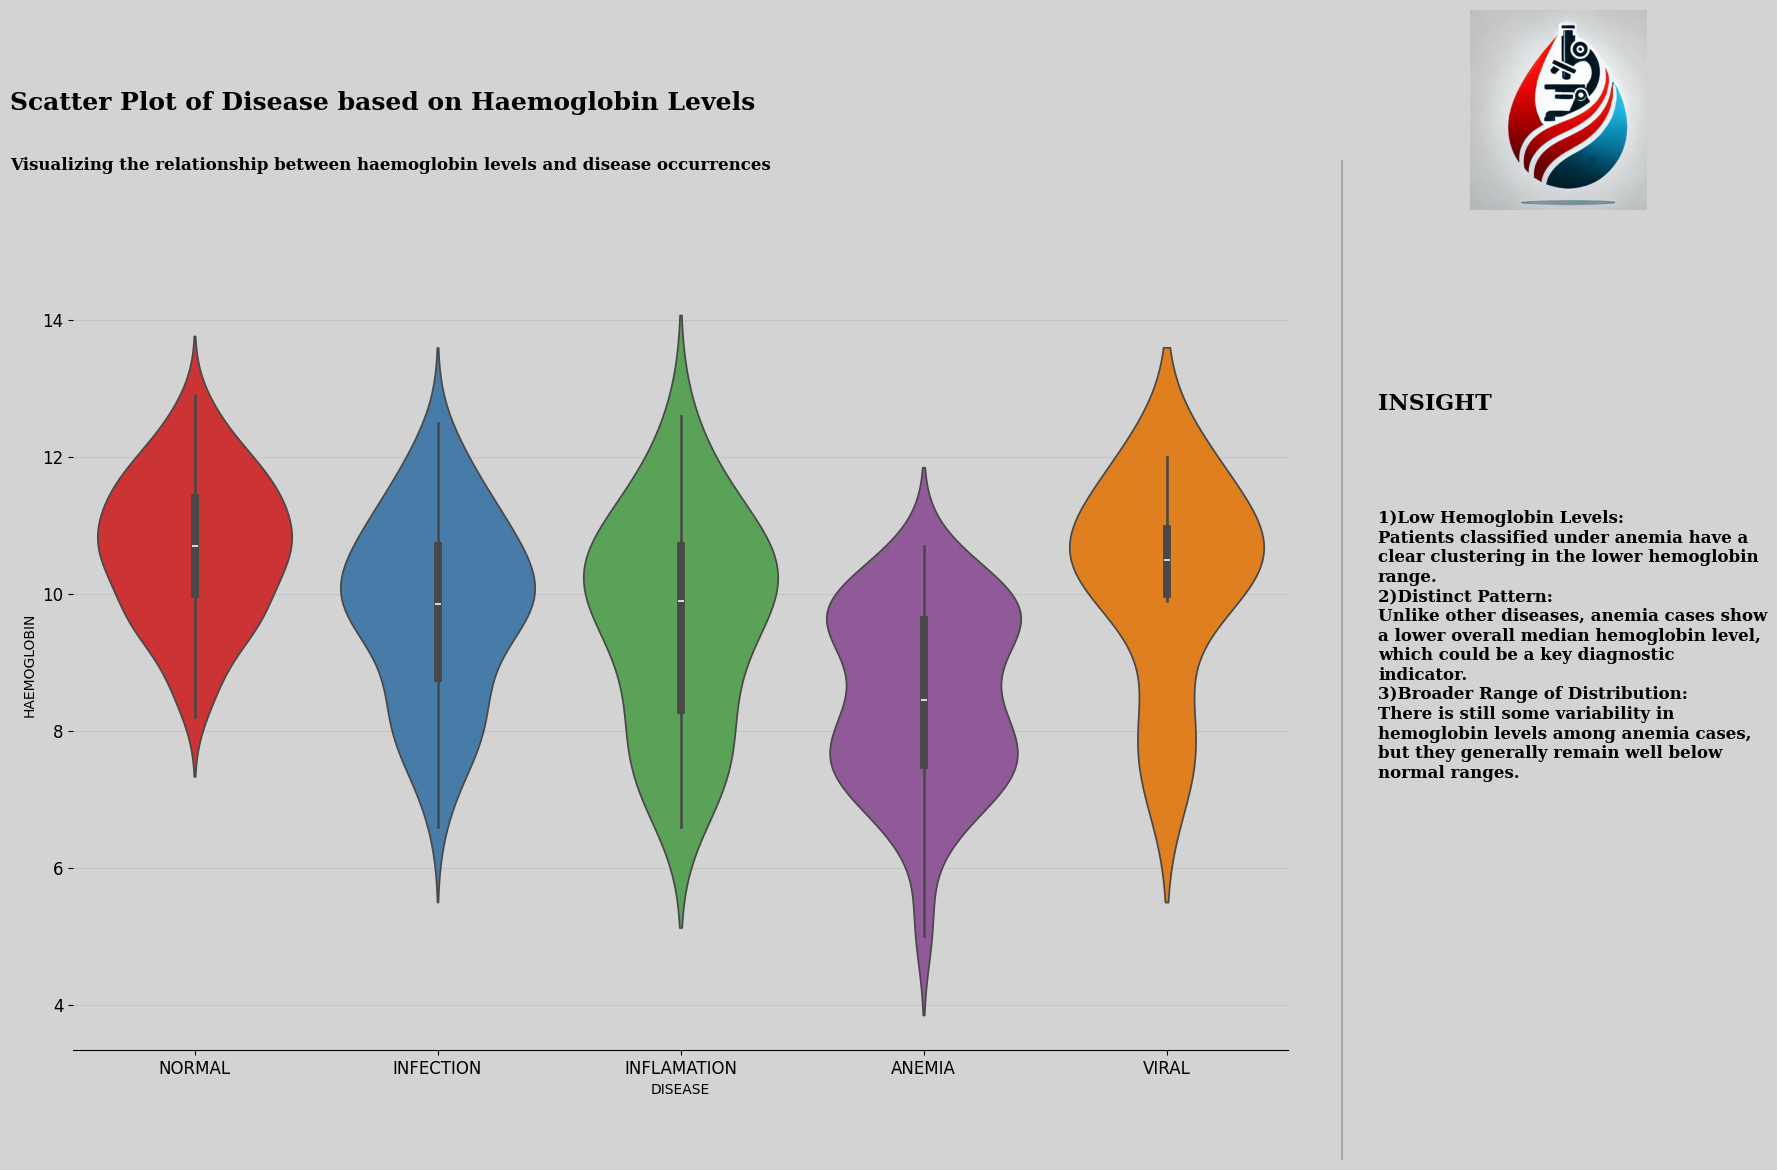

In [21]:
fig,ax=plt.subplots(figsize=(18, 10))

sns.violinplot(x=df["DISEASE"], y=df["HAEMOGLOBIN"], palette="Set1")
fig.subplots_adjust(right=0.8)
# Apply custom styling function
apply_chart_styling(
    ax=ax,
    fig=fig,
    title="Scatter Plot of Disease based on Haemoglobin Levels",
    subtitle="Visualizing the relationship between haemoglobin levels and disease occurrences",
    insight_text = '''1)Low Hemoglobin Levels: 
Patients classified under anemia have a clear clustering in the lower hemoglobin range.
2)Distinct Pattern: 
Unlike other diseases, anemia cases show a lower overall median hemoglobin level, which could be a key diagnostic indicator.
3)Broader Range of Distribution: 
There is still some variability in hemoglobin levels among anemia cases, but they generally remain well below normal ranges.'''

  ,
    logo_path="mscope.jpg"
)

plt.show()  # Display the plot

### Graph 5:CRP Level Visualizer

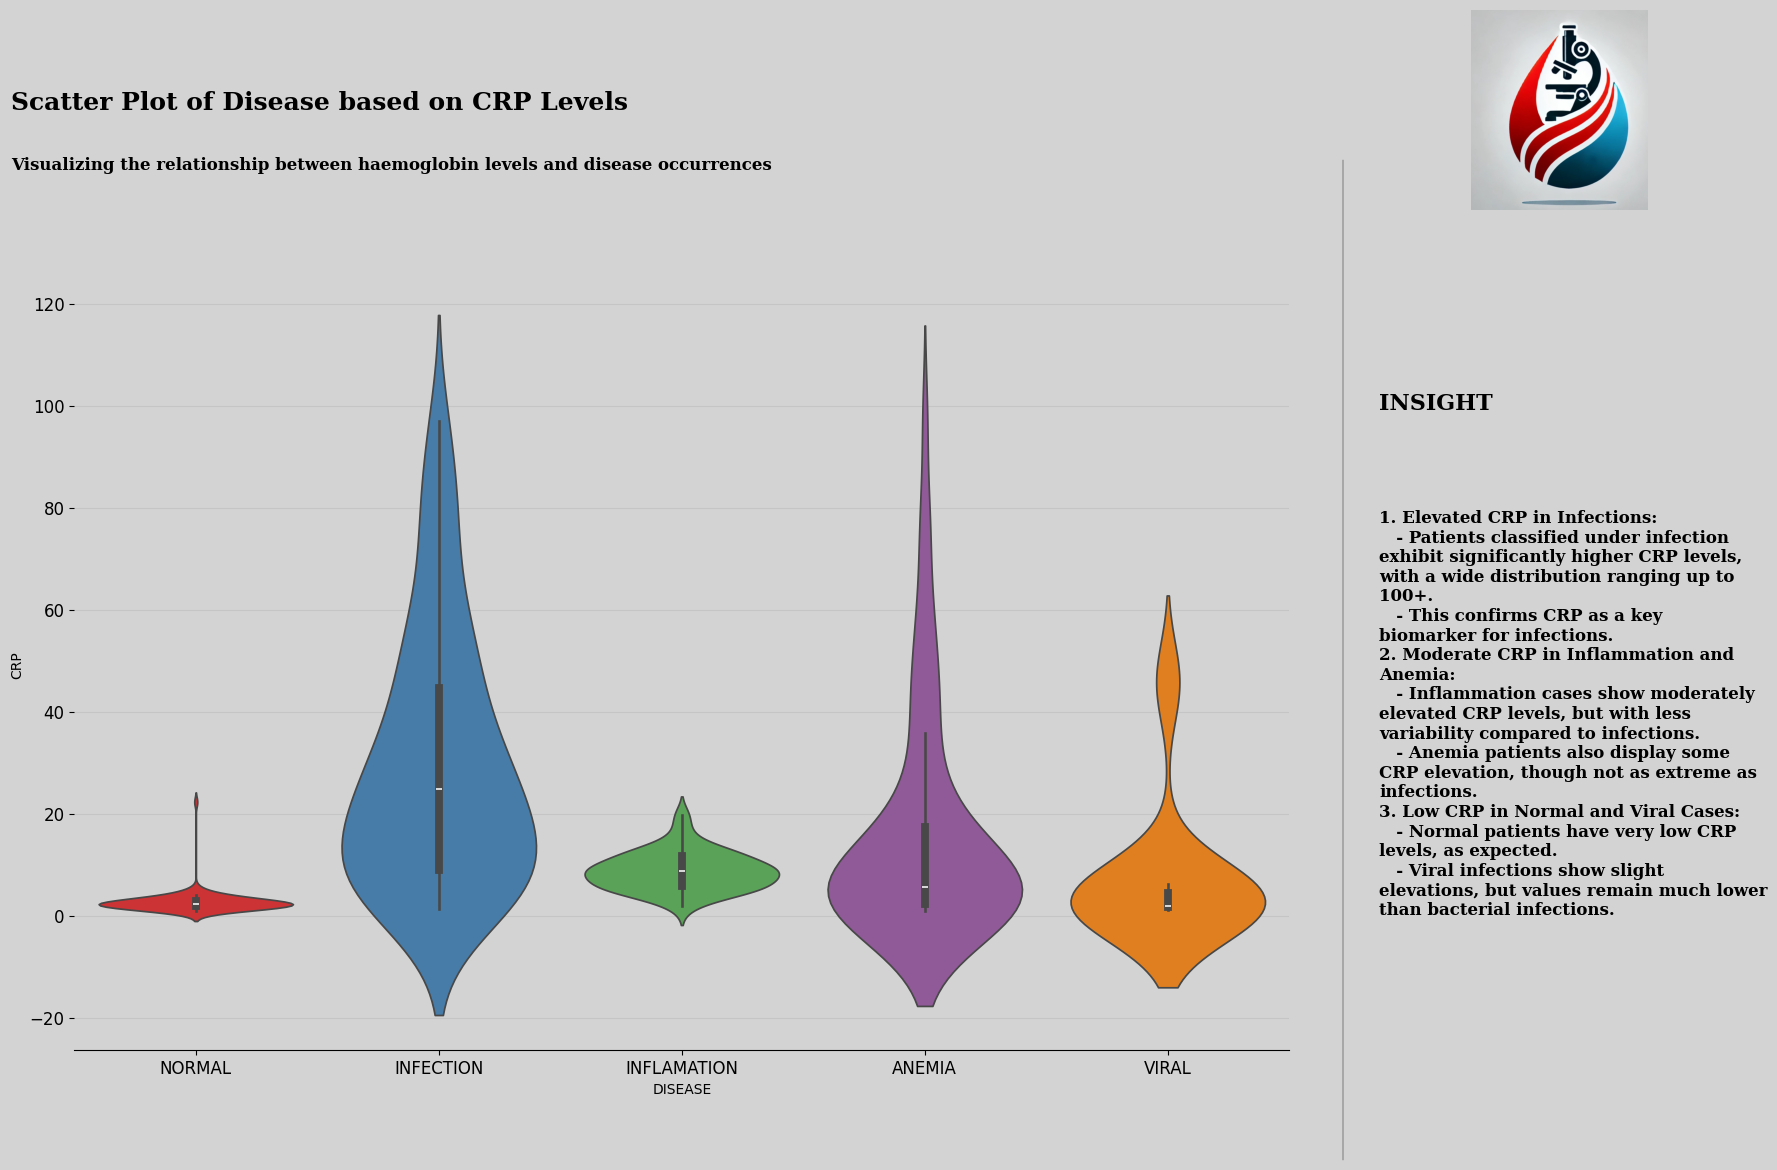

In [22]:
fig,ax=plt.subplots(figsize=(18, 10))

sns.violinplot(x=df["DISEASE"], y=df["CRP"], palette="Set1")
fig.subplots_adjust(right=0.8)

###############################################


# Apply custom styling function
apply_chart_styling(
    ax=ax,
    fig=fig,
    title="Scatter Plot of Disease based on CRP Levels",
    subtitle="Visualizing the relationship between haemoglobin levels and disease occurrences",
    insight_text='''
1. Elevated CRP in Infections:
   - Patients classified under infection exhibit significantly higher CRP levels, with a wide distribution ranging up to 100+.
   - This confirms CRP as a key biomarker for infections.

2. Moderate CRP in Inflammation and Anemia:
   - Inflammation cases show moderately elevated CRP levels, but with less variability compared to infections.
   - Anemia patients also display some CRP elevation, though not as extreme as infections.

3. Low CRP in Normal and Viral Cases:
   - Normal patients have very low CRP levels, as expected.
   - Viral infections show slight elevations, but values remain much lower than bacterial infections.
''',
    logo_path="mscope.jpg"
)

plt.show()

### Graph 6:Platelet Count Level Visualizer

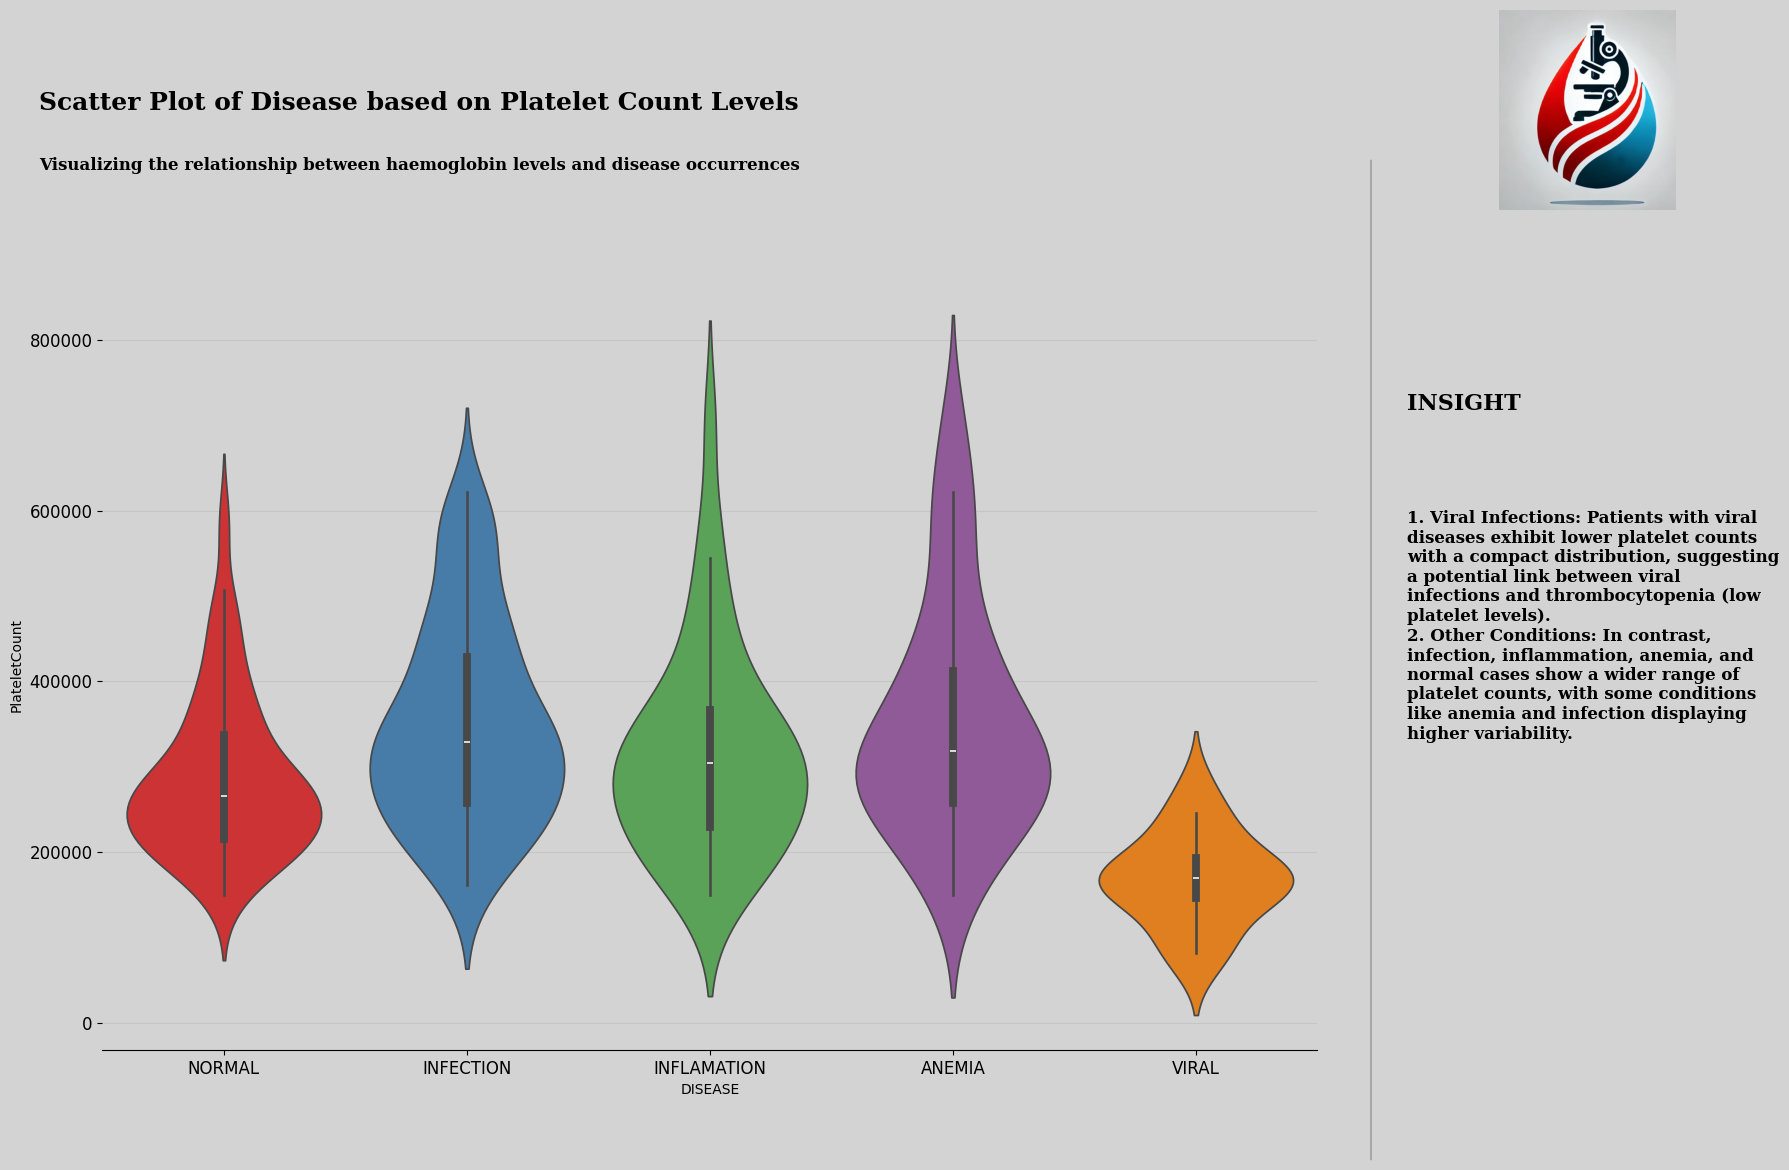

In [53]:
fig,ax=plt.subplots(figsize=(18, 10))

sns.violinplot(x=df["DISEASE"], y=df["PlateletCount"], palette="Set1")
fig.subplots_adjust(right=0.8)

###############################################


# Apply custom styling function
apply_chart_styling(
    ax=ax,
    fig=fig,
    title="Scatter Plot of Disease based on Platelet Count Levels",
    subtitle="Visualizing the relationship between haemoglobin levels and disease occurrences",
    insight_text="""1. Viral Infections: Patients with viral diseases exhibit lower platelet counts with a compact distribution, suggesting a potential link between viral infections and thrombocytopenia (low platelet levels).  

2. Other Conditions: In contrast, infection, inflammation, anemia, and normal cases show a wider range of platelet counts, with some conditions like anemia and infection displaying higher variability.""",
    logo_path="mscope.jpg"
)

plt.show()

### Graph 7:Total WBC Count Levels

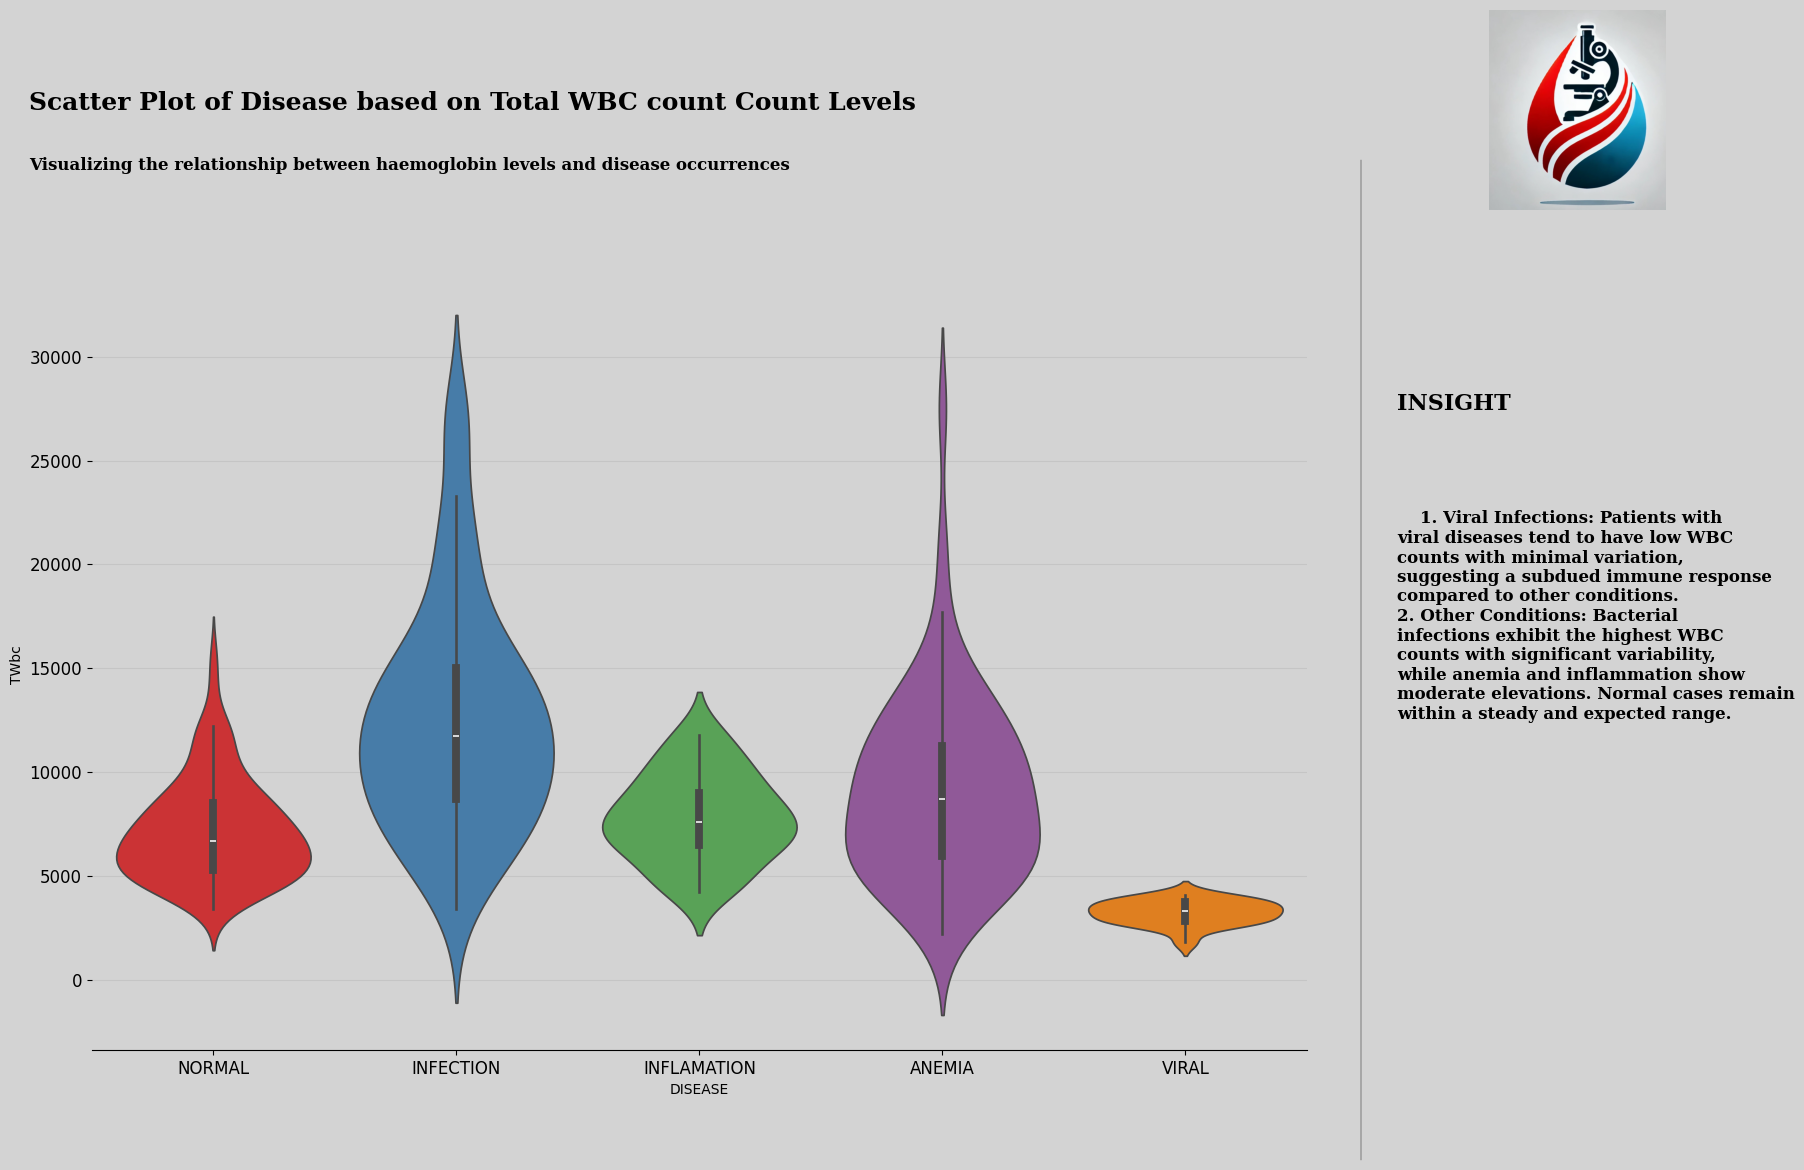

In [24]:
fig,ax=plt.subplots(figsize=(18, 10))

sns.violinplot(x=df["DISEASE"], y=df["TWbc"], palette="Set1")

fig.subplots_adjust(right=0.8)
###############################################


# Apply custom styling function
apply_chart_styling(
    ax=ax,
    fig=fig,
    title="Scatter Plot of Disease based on Total WBC count Count Levels",
    subtitle="Visualizing the relationship between haemoglobin levels and disease occurrences",
    insight_text="""
    1. Viral Infections: Patients with viral diseases tend to have low WBC counts with minimal variation, suggesting a subdued immune response compared to other conditions.

2. Other Conditions: Bacterial infections exhibit the highest WBC counts with significant variability, while anemia and inflammation show moderate elevations. Normal cases remain within a steady and expected range.
    """,
    logo_path="mscope.jpg"
)

plt.show()

## Preprocessing Data For Model Training

In [25]:
df_modify= pd.get_dummies(df, columns=['DISEASE'])

In [26]:
df_modify = df_modify.groupby('Pid').agg({
    'AGE': 'first',
    'SEX': 'first',
    'HAEMOGLOBIN': 'first',
    'TWbc': 'first',
    'PlateletCount': 'first',
    'CRP': 'first',
    'DISEASE_ANEMIA': 'max',
    'DISEASE_INFECTION': 'max',
    'DISEASE_INFLAMATION': 'max',
    'DISEASE_NORMAL': 'max',
    'DISEASE_VIRAL': 'max'
}).reset_index()

In [27]:
df_modify = df_modify.rename(columns={
    'DISEASE_ANEMIA': 'Anemia',
    'DISEASE_INFECTION': 'Infection',
    'DISEASE_INFLAMATION': 'Inflamation',
    'DISEASE_NORMAL': 'Normal',
    'DISEASE_VIRAL': 'Viral'
})

In [28]:
df_modify=df_modify.drop(columns=['Pid'],axis=1)

In [29]:
df_modify.head()

,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Anemia,Infection,Inflamation,Normal,Viral
0,6.0,F,7.8,4000.0,225000.0,24.86,True,True,False,False,False
1,6.0,M,9.5,5100.0,163000.0,5.04,True,False,True,False,False
2,1.6,M,8.4,6800.0,291000.0,2.86,False,False,False,True,False
3,14.0,M,10.1,4200.0,175000.0,19.76,False,False,True,False,False
4,3.9,F,11.8,7200.0,362000.0,3.35,False,False,False,True,False


In [30]:
df_modify.isna().sum()

AGE              0
SEX              0
HAEMOGLOBIN      0
TWbc             0
PlateletCount    0
CRP              0
Anemia           0
Infection        0
Inflamation      0
Normal           0
Viral            0
dtype: int64

In [31]:
df_modify['SEX'] = df_modify['SEX'].map({'M': 1, 'F': 0})

In [32]:
df_modify.sample(5)

,AGE,SEX,HAEMOGLOBIN,TWbc,PlateletCount,CRP,Anemia,Infection,Inflamation,Normal,Viral
85,2.5,0,6.3,6900.0,264000.0,2.20,True,False,False,False,False
238,3.5,0,10.7,15200.0,294000.0,28.79,False,True,False,False,False
228,1.7,0,9.8,15200.0,398000.0,13.79,True,True,False,False,False
35,1.0,1,10.6,15500.0,448000.0,1.85,False,False,False,True,False
140,4.0,1,11.7,6600.0,258000.0,26.10,False,True,False,False,False


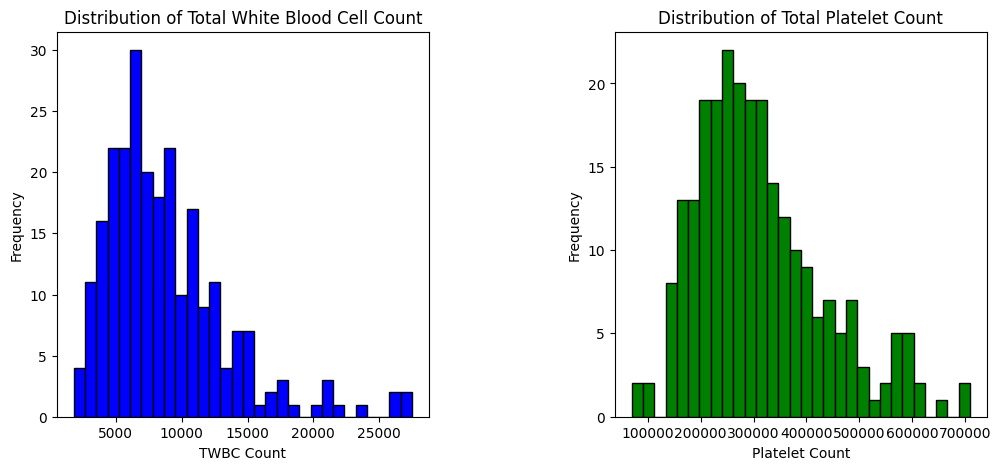

In [33]:
plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.5)  # Adjust wspace

ax1 = plt.subplot(gs[0])
ax1.hist(df_modify['TWbc'], bins=30, color='blue', edgecolor='black')
ax1.set_title('Distribution of Total White Blood Cell Count')
ax1.set_xlabel('TWBC Count')
ax1.set_ylabel('Frequency')

ax2 = plt.subplot(gs[1])
ax2.hist(df_modify['PlateletCount'], bins=30, color='green', edgecolor='black')
ax2.set_title('Distribution of Total Platelet Count')
ax2.set_xlabel('Platelet Count')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [34]:
df_modify['TWbc'] = np.log1p(df_modify['TWbc'])  # log1p handles zero values safely
df_modify['PlateletCount'] = np.log1p(df_modify['PlateletCount'])

In [35]:
df_modify.columns

Index(['AGE', 'SEX', 'HAEMOGLOBIN', 'TWbc', 'PlateletCount', 'CRP', 'Anemia',
       'Infection', 'Inflamation', 'Normal', 'Viral'],
      dtype='object')

### Train Test Split Data

In [36]:
X=df_modify.drop(columns=['Inflamation','Normal','Viral','Infection','Anemia'],axis=1)
y = df_modify[['Inflamation', 'Normal', 'Viral', 'Infection', 'Anemia']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 

## XGboost

In [37]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

# Train separate models for each label with GridSearch
best_models = {}

for column in y.columns:
    print(f"Optimizing model for {column}...")

    # Initialize XGBClassifier
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

    # Perform Grid Search
    grid_search = GridSearchCV(model, param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train[column])

    # Store best model
    best_models[column] = grid_search.best_estimator_

    print(f"{column} - Best Params: {grid_search.best_params_}")

Optimizing model for Inflamation...
Inflamation - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Optimizing model for Normal...
Normal - Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Optimizing model for Viral...
Viral - Best Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Optimizing model for Infection...
Infection - Best Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Optimizing model for Anemia...
Anemia - Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [38]:
trained_models = {}

for column in y.columns:
    print(f"Training best model for {column}...")

    # Get best hyperparameters
    best_params = best_models[column].get_params()

    # Train the model using best parameters
    model = XGBClassifier(**best_params)
    model.fit(X_train, y_train[column])

    # Store trained model
    trained_models[column] = model

    print(f"{column} - Training complete")

Training best model for Inflamation...
Inflamation - Training complete
Training best model for Normal...
Normal - Training complete
Training best model for Viral...
Viral - Training complete
Training best model for Infection...
Infection - Training complete
Training best model for Anemia...
Anemia - Training complete


In [39]:
accuracy_results={}

for column in y.columns:
    print(f"Evaluating accuracy for {column}...")

    # Get the trained model
    model = trained_models[column]

    # Make predictions on test data
    y_pred = model.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test[column], y_pred)

    # Store results
    accuracy_results[column] = accuracy

    print(f"{column} - Accuracy: {accuracy:.4f}")

Evaluating accuracy for Inflamation...
Inflamation - Accuracy: 0.9000
Evaluating accuracy for Normal...
Normal - Accuracy: 0.9000
Evaluating accuracy for Viral...
Viral - Accuracy: 1.0000
Evaluating accuracy for Infection...
Infection - Accuracy: 0.8800
Evaluating accuracy for Anemia...
Anemia - Accuracy: 0.8800


## Feature Importance Related To Diseases

In [62]:
def plot_feature_importance(model, feature_names, title="Feature Importance", 
                            subtitle="Key features contributing to model prediction", 
                            insight_text=None):
    importances = model.feature_importances_
    
    # Sort features by importance
    sorted_idx = importances.argsort()
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_importances = importances[sorted_idx]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(18, 10))
    sns.barplot(x=sorted_importances, y=sorted_features, ax=ax, palette="coolwarm")
    
    # Apply your custom style
     # Apply your custom style
    apply_chart_styling(
        ax, fig,
        title=title,
        subtitle=subtitle,
        insight_text=insight_text,
        logo_path="mscope.jpg"
    )

    plt.tight_layout()
    plt.show()

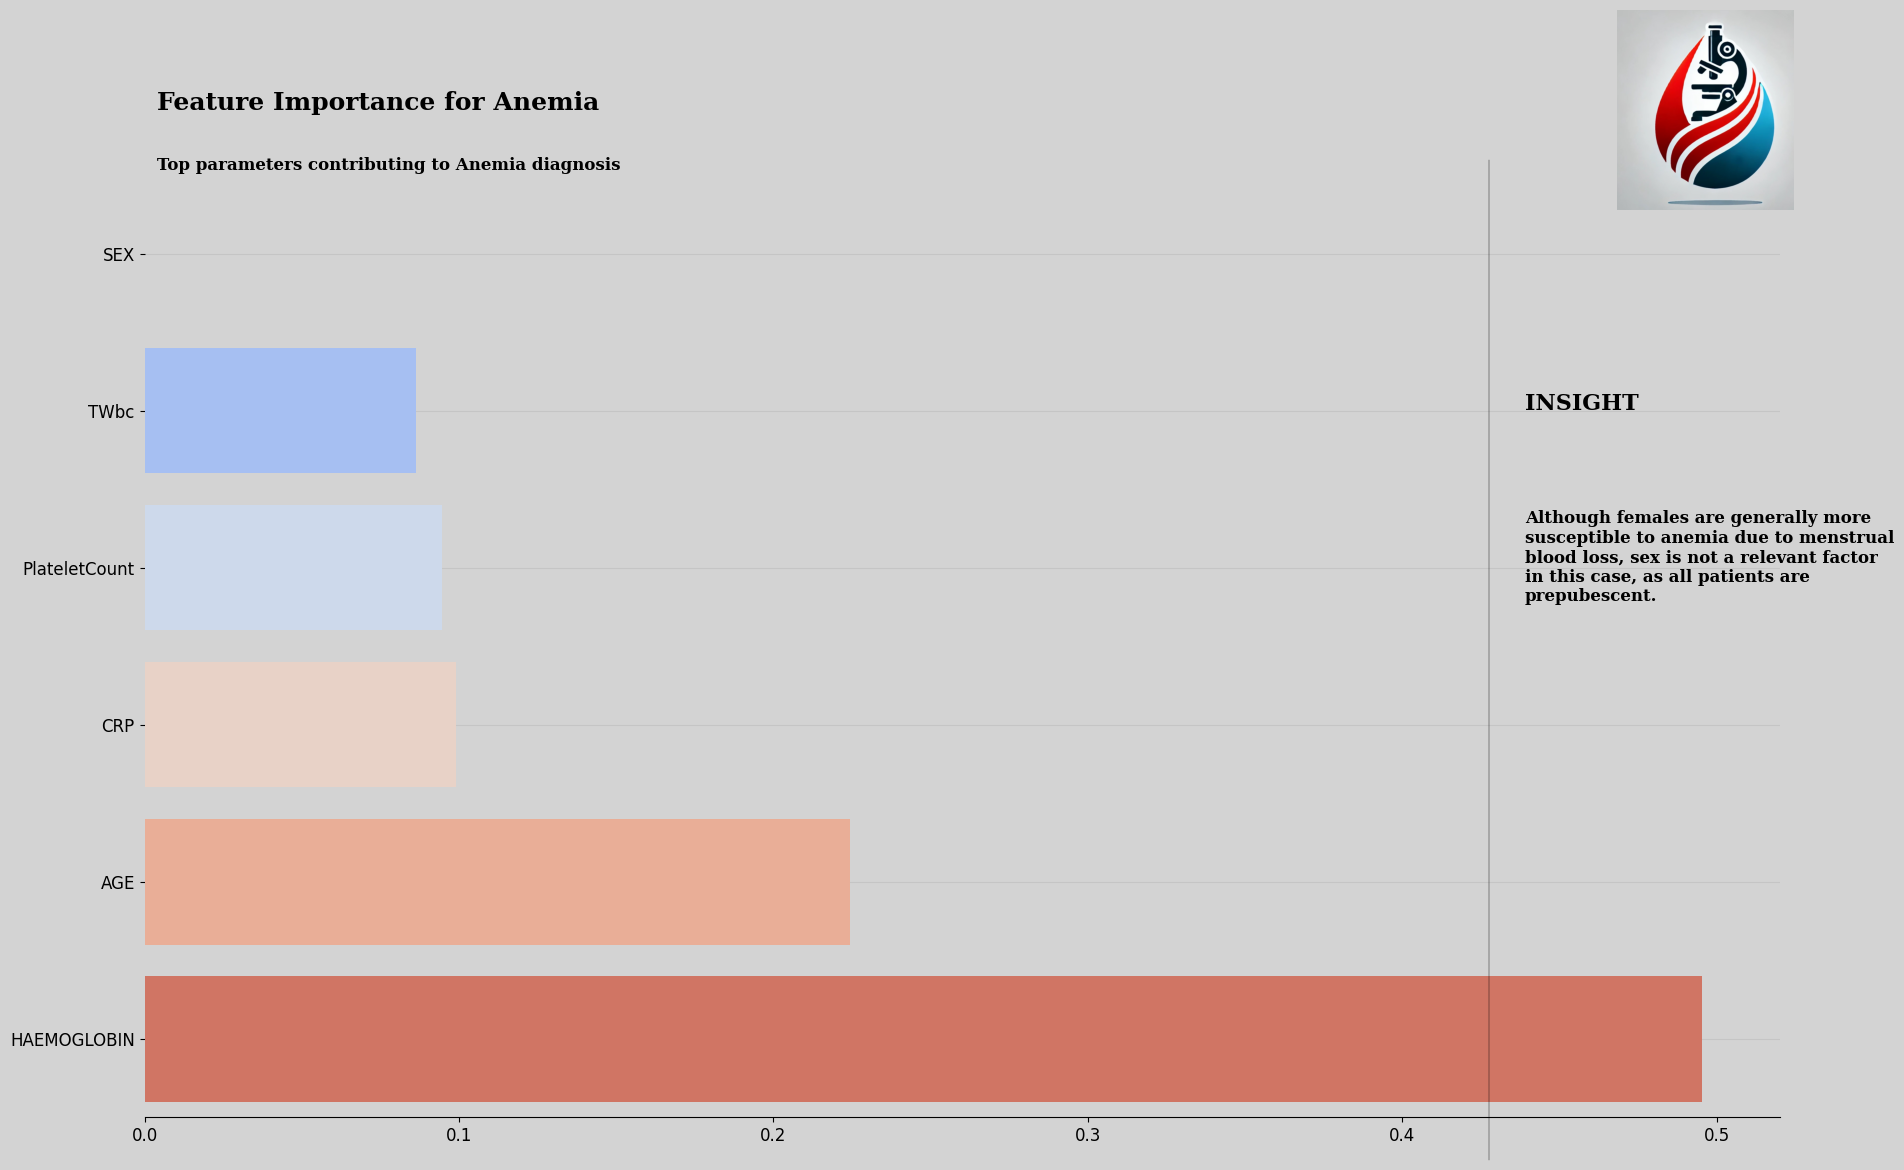

In [63]:
feature_names = X_train.columns.tolist()
plot_feature_importance(trained_models['Anemia'], feature_names, title="Feature Importance for Anemia",
    subtitle="Top parameters contributing to Anemia diagnosis",
    insight_text="Although females are generally more susceptible to anemia due to menstrual blood loss, sex is not a relevant factor in this case, as all patients are prepubescent.")


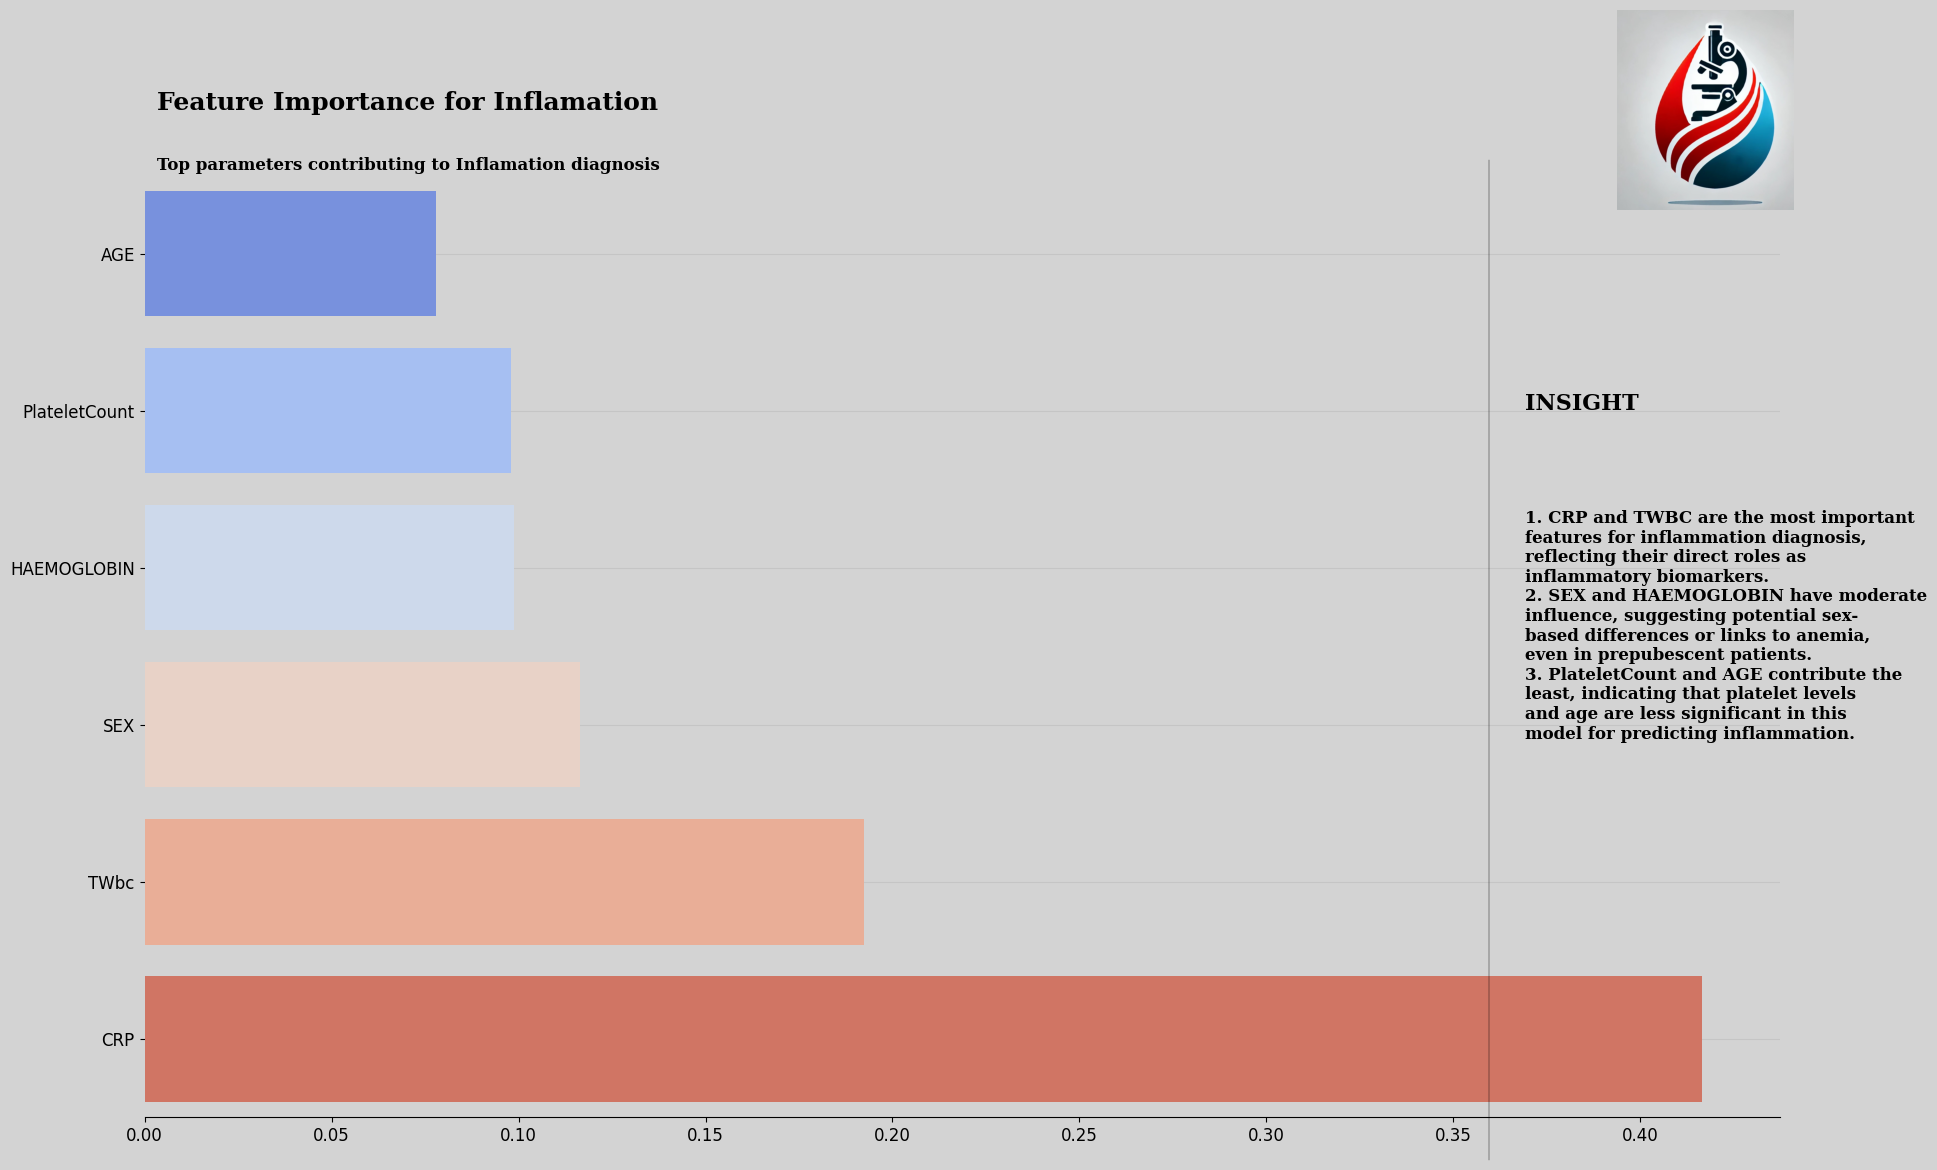

In [66]:
feature_names = X_train.columns.tolist()
plot_feature_importance(trained_models['Inflamation'], feature_names, title="Feature Importance for Inflamation",
    subtitle="Top parameters contributing to Inflamation diagnosis",
    insight_text="""1. CRP and TWBC are the most important features for inflammation diagnosis, reflecting their direct roles as inflammatory biomarkers.\n  

2. SEX and HAEMOGLOBIN have moderate influence, suggesting potential sex-based differences or links to anemia, even in prepubescent patients.\n  

3. PlateletCount and AGE contribute the least, indicating that platelet levels and age are less significant in this model for predicting inflammation.""")



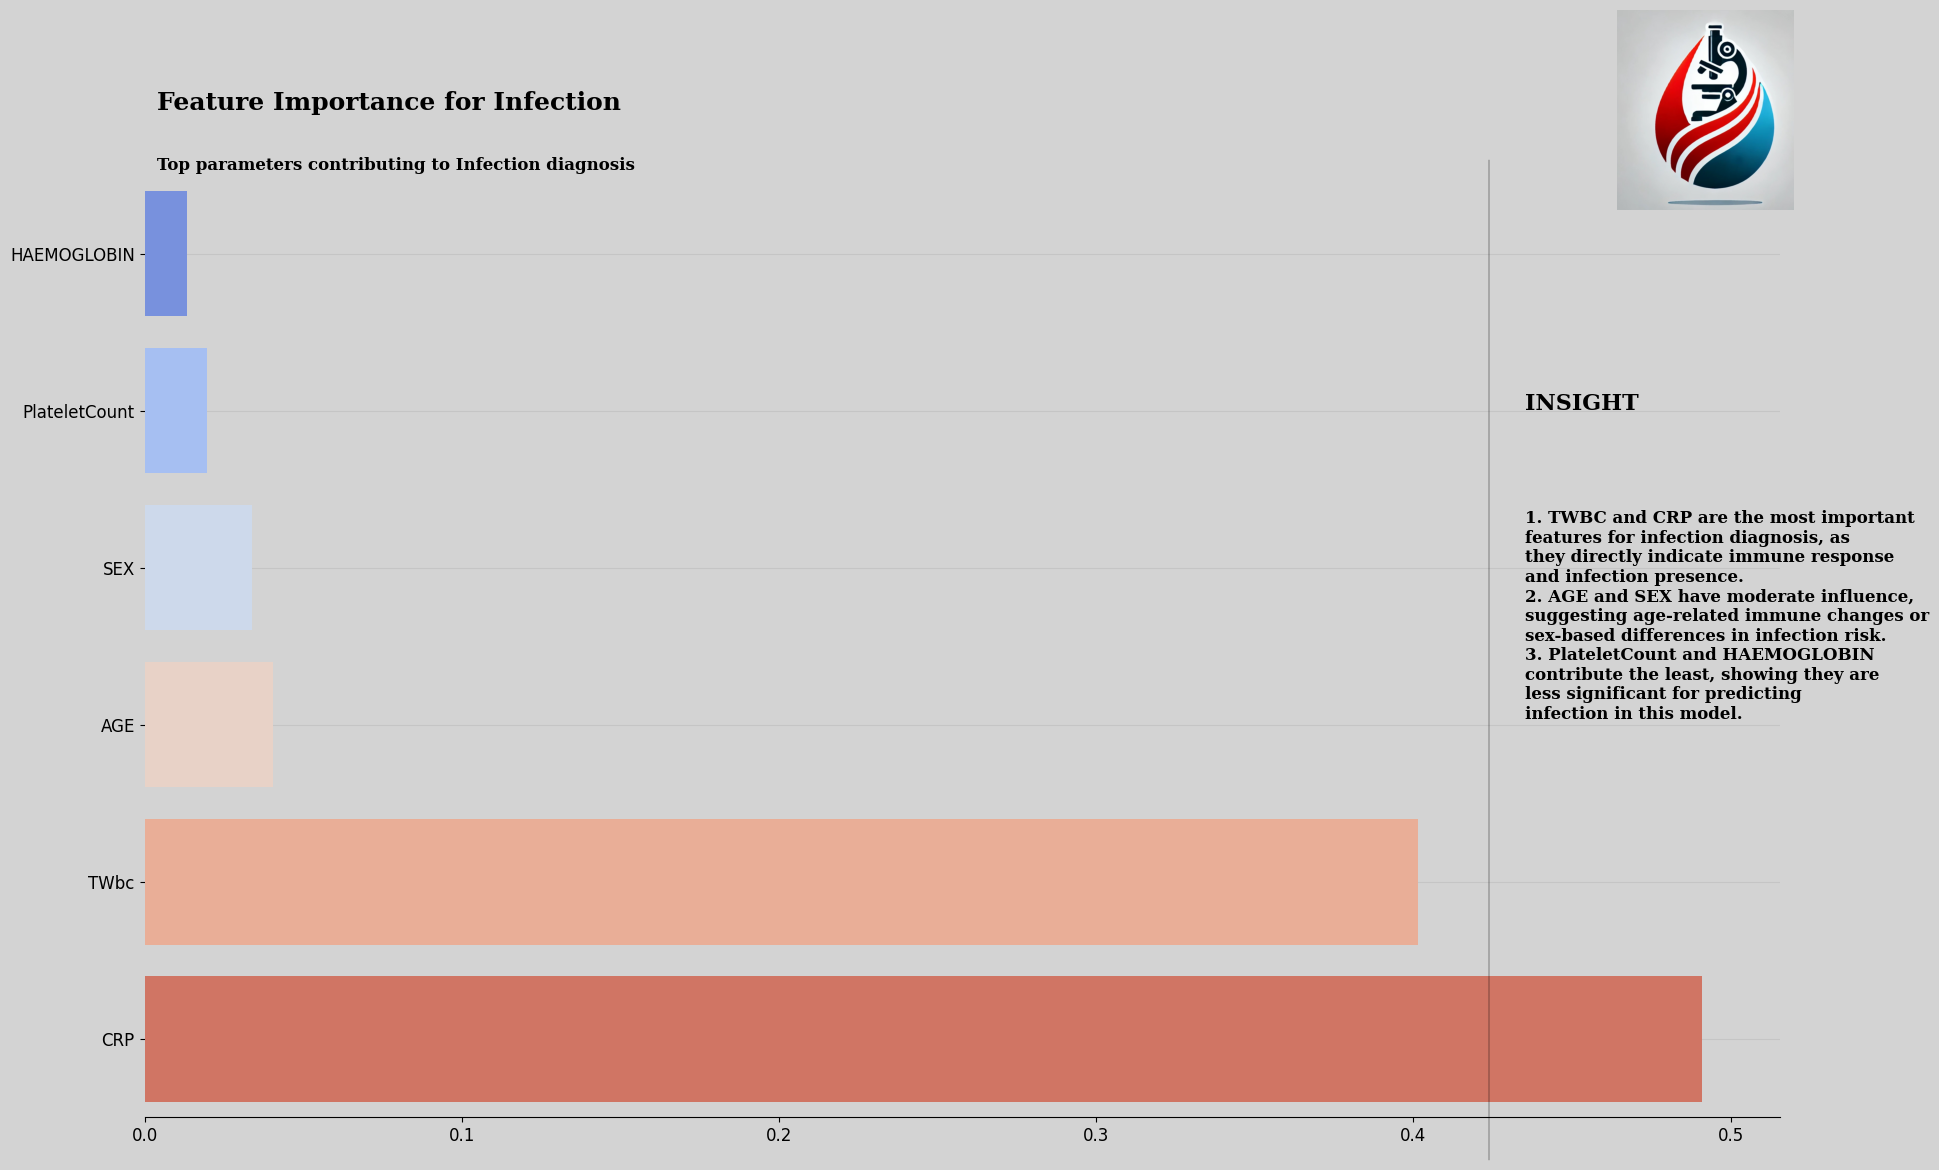

In [69]:
feature_names = X_train.columns.tolist()
plot_feature_importance(trained_models['Infection'], feature_names, title="Feature Importance for Infection",
    subtitle="Top parameters contributing to Infection diagnosis",
    insight_text="""1. TWBC and CRP are the most important features for infection diagnosis, as they directly indicate immune response and infection presence.  

2. AGE and SEX have moderate influence, suggesting age-related immune changes or sex-based differences in infection risk.  

3. PlateletCount and HAEMOGLOBIN contribute the least, showing they are less significant for predicting infection in this model.""")



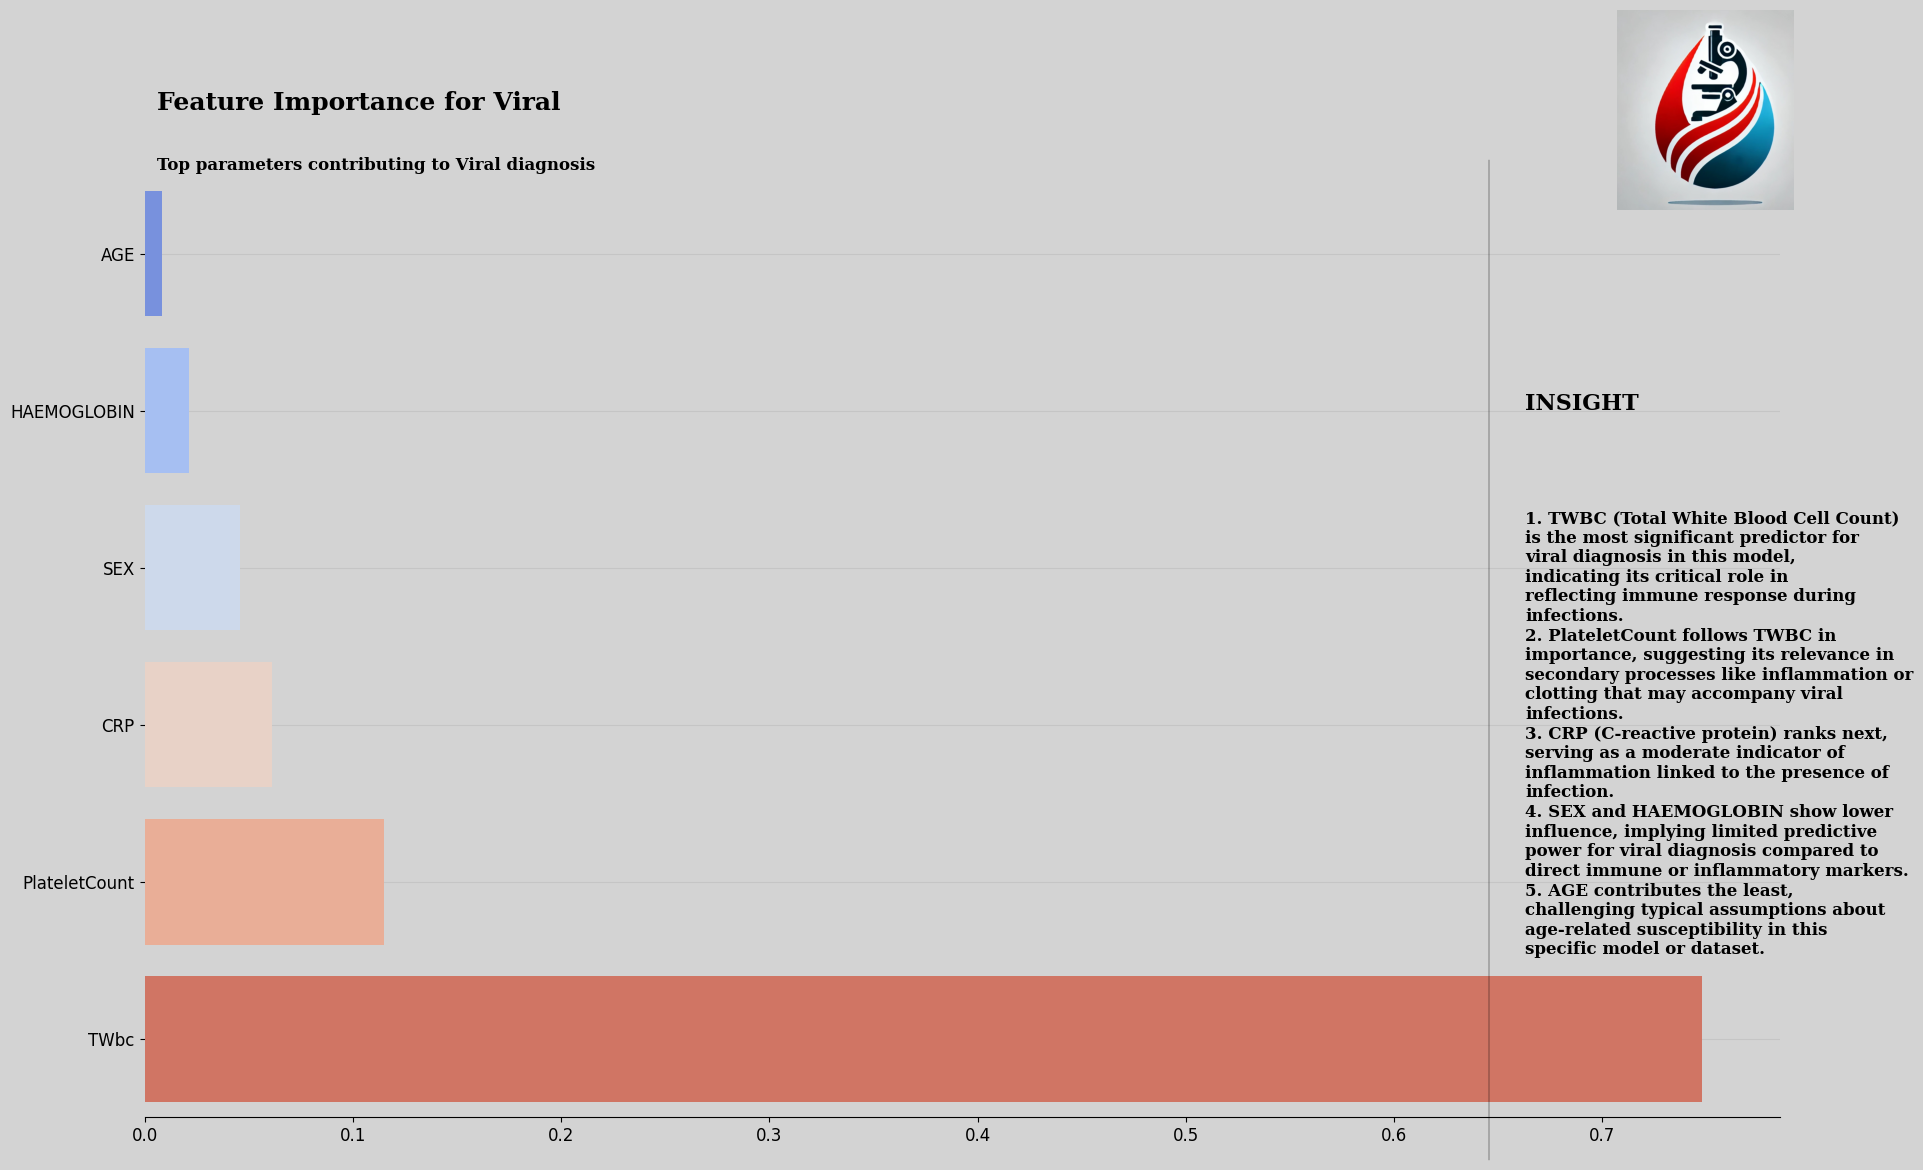

In [71]:
feature_names = X_train.columns.tolist()
plot_feature_importance(trained_models['Viral'], feature_names, title="Feature Importance for Viral",
    subtitle="Top parameters contributing to Viral diagnosis",
    insight_text="""1. TWBC (Total White Blood Cell Count) is the most significant predictor for viral diagnosis in this model, indicating its critical role in reflecting immune response during infections.  
2. PlateletCount follows TWBC in importance, suggesting its relevance in secondary processes like inflammation or clotting that may accompany viral infections.  
3. CRP (C-reactive protein) ranks next, serving as a moderate indicator of inflammation linked to the presence of infection.  
4. SEX and HAEMOGLOBIN show lower influence, implying limited predictive power for viral diagnosis compared to direct immune or inflammatory markers.  
5. AGE contributes the least, challenging typical assumptions about age-related susceptibility in this specific model or dataset.""")



##  Disease Prediction Through XGBoost Algorithm

In [42]:
def create_test(age, sex, haemoglobin, twbc, platelet_count, crp):
    # Convert sex to numeric (M -> 1, F -> 0)
    sex = 1 if sex == 'M' else 0
    
    # Apply log transformation
    twbc = np.log1p(twbc)
    platelet_count = np.log1p(platelet_count)

    # Create a DataFrame with the transformed values
    X_test = pd.DataFrame([[age, sex, haemoglobin, twbc, platelet_count, crp]], 
                          columns=['AGE', 'SEX', 'HAEMOGLOBIN', 'TWbc', 'PlateletCount', 'CRP'])
    return X_test

In [43]:

test_data=create_test(1.3,'F',9.9,9200,424000,2.83)

for column in y.columns:

    # Get the trained model
    model = trained_models[column]
    
    # Make predictions on test data
    y_pred = model.predict(test_data)
    print(f"Chance of {column} is: {y_pred}")
    

Chance of Inflamation is: [0]
Chance of Normal is: [1]
Chance of Viral is: [0]
Chance of Infection is: [0]
Chance of Anemia is: [0]
